In [1]:
from SCFT_functions import *
from DNA_input import *

import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange

Using cupy


(9, 751)


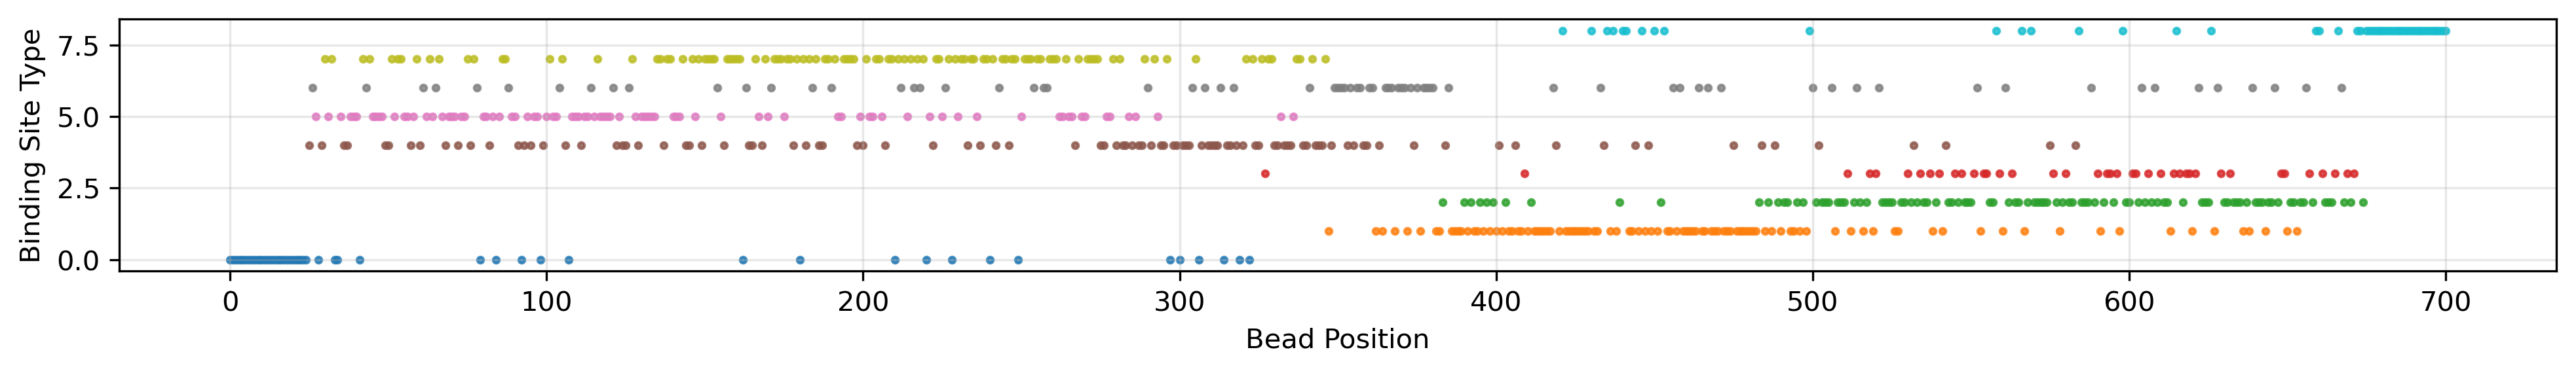

In [2]:
ns = 750
chain_interaction_binary = IMR90_data(ns, split_class_zero=True, clip = [25,-25])
#chain_interaction_binary = IMR90_data(ns, split_class_zero=True)
ns = chain_interaction_binary.shape[1]-1

[0.12058824 0.08088235 0.17352941 0.11470588 0.15735294 0.11617647
 0.23676471]


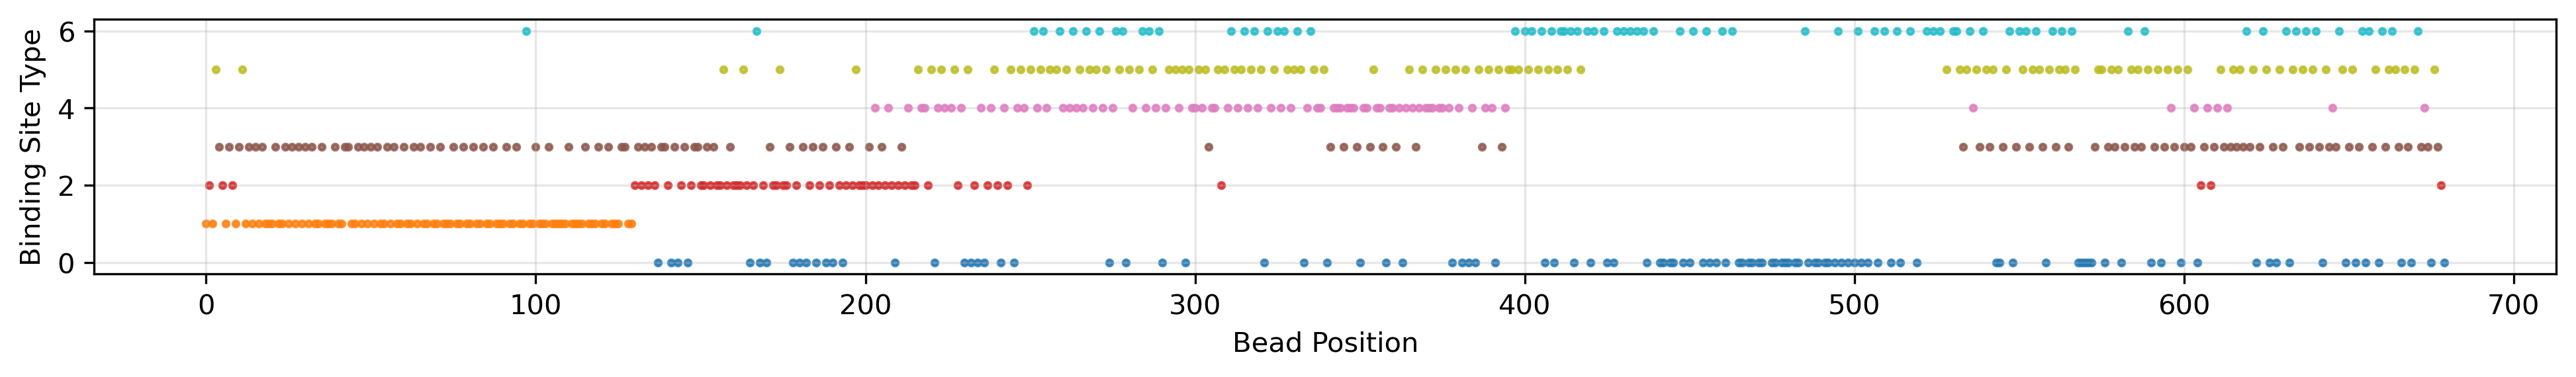

In [2]:
infered_sequence = np.load("../Bead_sequence_MC/IMR90_infer_sequence_34_43.npy")
visualize_config(infered_sequence, np.max(infered_sequence))
chain_interaction_binary = colors_to_onehot(infered_sequence)
ns = chain_interaction_binary.shape[1]-1

print(np.mean(chain_interaction_binary, axis = 1))

[0.11044177 0.06927711 0.09538153 0.02710843 0.08333333 0.05722892
 0.13554217 0.02409639 0.04919679 0.15160643 0.10742972 0.08935743]


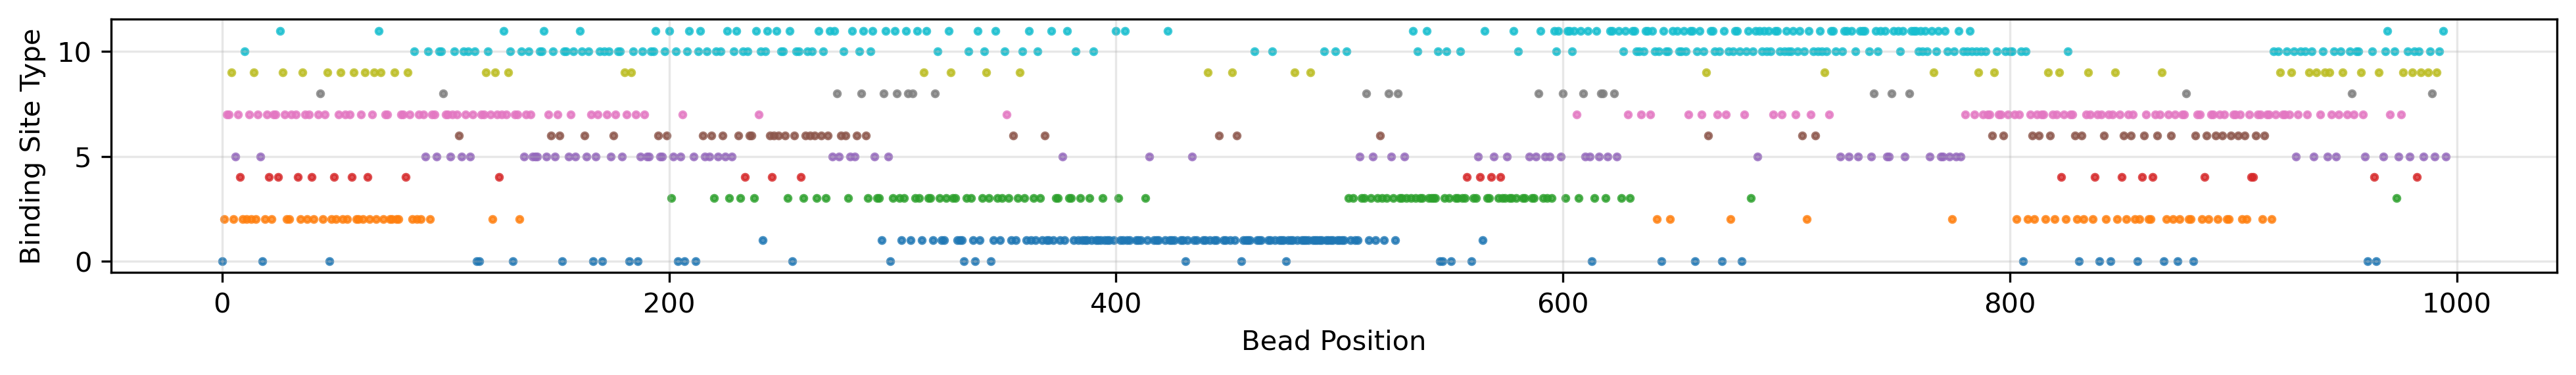

In [2]:
infered_sequence = np.load("../Bead_sequence_MC/IMR90_infer_sequence_30_42.npy")
visualize_config(infered_sequence, np.max(infered_sequence))
chain_interaction_binary = colors_to_onehot(infered_sequence)
ns = chain_interaction_binary.shape[1]-1

print(np.mean(chain_interaction_binary, axis = 1))

chain_interaction_binary_temp = np.zeros((chain_interaction_binary.shape[0]+2,chain_interaction_binary.shape[1]+40))
chain_interaction_binary_temp[1:-1,20:-20] = chain_interaction_binary
chain_interaction_binary_temp[0, 0:20] = 1
chain_interaction_binary_temp[-1, -20:] = 1

ns = chain_interaction_binary_temp.shape[1]-1

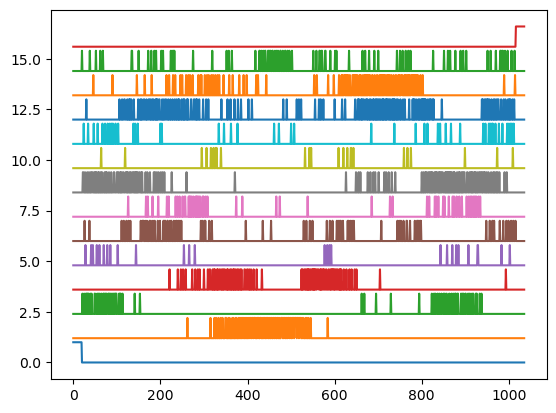

In [3]:
for i in range(chain_interaction_binary_temp.shape[0]):
    plt.plot(chain_interaction_binary_temp[i]+i*1.2)

In [4]:
AB_binding_class_epigenetics = np.load("AB_binding_class_epigenetics.npy")
print(AB_binding_class_epigenetics)
print(AB_binding_class_epigenetics.shape)

AB_binding_class_epigenetics_temp = np.zeros(AB_binding_class_epigenetics.shape[0]+2)
AB_binding_class_epigenetics_temp[1:-1] = AB_binding_class_epigenetics
print(AB_binding_class_epigenetics_temp)

[1. 1. 1. 1. 0. 1. 0. 1. 0. 0. 1. 1.]
(12,)
[0. 1. 1. 1. 1. 0. 1. 0. 1. 0. 0. 1. 1. 0.]


In [5]:
PP = 450
PS = 325

chi_pp = PP*xp.ones((AB_binding_class_epigenetics_temp.shape[0],AB_binding_class_epigenetics_temp.shape[0]))
chi_ps = PS*xp.ones(AB_binding_class_epigenetics_temp.shape[0])

chi_offset = 20

for i in range(AB_binding_class_epigenetics_temp.shape[0]):
    if AB_binding_class_epigenetics_temp[i]==0:
        chi_ps[i] = PS+chi_offset
    else:
        chi_ps[i] = PS-chi_offset
    for j in range(AB_binding_class_epigenetics_temp.shape[0]):
        if (AB_binding_class_epigenetics_temp[i]==0) ^ (AB_binding_class_epigenetics_temp[j]==0):
            chi_pp[i, j] = PP+chi_offset
        elif AB_binding_class_epigenetics_temp[i]==1 and AB_binding_class_epigenetics_temp[j]==1:
            chi_pp[i, j] = PP-chi_offset



end_interaction_strength_ps = PS+50
end_interaction_strength_pp = PP+50

chi_ps[0] = end_interaction_strength_ps
chi_ps[-1] = end_interaction_strength_ps

chi_pp[0, :] = end_interaction_strength_pp
chi_pp[-1, :] = end_interaction_strength_pp
chi_pp[:, 0] = end_interaction_strength_pp
chi_pp[:, -1] = end_interaction_strength_pp

print(chi_pp)
print(chi_ps)

N = 200

nx = ny = 128

L = 30 #dimension of the box

width_gaussian = nx // 4
x = np.linspace(-1, 1, width_gaussian)
y = np.linspace(-1, 1, width_gaussian)
X, Y = np.meshgrid(x, y, indexing='ij')
gaussian = np.exp(-(X**2 + Y**2)/0.1)
boundary = np.zeros((nx,ny))
boundary[nx//2-width_gaussian//2:nx//2+width_gaussian//2,nx//2-width_gaussian//2:nx//2+width_gaussian//2] += gaussian

boundary = xp.random.rand(nx,ny)
#boundary = xp.ones((nx, ny))

polymer = Scft(
    N = N,
    Lx=L, Ly=L,
    phibar=0.1, # volume fraction of polymer
    l_p=xp.sqrt(N),
    n_seg=1, # contour length of polymer normalized from 0-1
    nx=nx, ny=ny,
    ns=ns,
    iterations=7000,
    error_tol=1e-12,
    chain_interaction=xp.asarray(chain_interaction_binary_temp),
    self_avoiding=0,
    initial_qsr=xp.array(boundary),
    mixing_rate=0.004,
    chi_polymer_block = chi_pp,
    chi_polymer_s = chi_ps,
    PB = 1,
    close_boundary=True,

)

[[500. 500. 500. 500. 500. 500. 500. 500. 500. 500. 500. 500. 500. 500.]
 [500. 430. 430. 430. 430. 470. 430. 470. 430. 470. 470. 430. 430. 500.]
 [500. 430. 430. 430. 430. 470. 430. 470. 430. 470. 470. 430. 430. 500.]
 [500. 430. 430. 430. 430. 470. 430. 470. 430. 470. 470. 430. 430. 500.]
 [500. 430. 430. 430. 430. 470. 430. 470. 430. 470. 470. 430. 430. 500.]
 [500. 470. 470. 470. 470. 450. 470. 450. 470. 450. 450. 470. 470. 500.]
 [500. 430. 430. 430. 430. 470. 430. 470. 430. 470. 470. 430. 430. 500.]
 [500. 470. 470. 470. 470. 450. 470. 450. 470. 450. 450. 470. 470. 500.]
 [500. 430. 430. 430. 430. 470. 430. 470. 430. 470. 470. 430. 430. 500.]
 [500. 470. 470. 470. 470. 450. 470. 450. 470. 450. 450. 470. 470. 500.]
 [500. 470. 470. 470. 470. 450. 470. 450. 470. 450. 450. 470. 470. 500.]
 [500. 430. 430. 430. 430. 470. 430. 470. 430. 470. 470. 430. 430. 500.]
 [500. 430. 430. 430. 430. 470. 430. 470. 430. 470. 470. 430. 430. 500.]
 [500. 500. 500. 500. 500. 500. 500. 500. 500. 500.

In [3]:
chi_pp = 250*xp.ones((chain_interaction_binary.shape[0],chain_interaction_binary.shape[0]))
chi_ps = 325*xp.ones(chain_interaction_binary.shape[0])

end_interaction_strength_ps = 300
end_interaction_strength_pp = 375

chi_ps[0] = end_interaction_strength_ps
chi_ps[-1] = end_interaction_strength_ps
chi_pp[0, :] = end_interaction_strength_ps
chi_pp[-1, :] = end_interaction_strength_pp
chi_pp[:, 0] = end_interaction_strength_pp
chi_pp[:, -1] = end_interaction_strength_pp

N = 200

nx = ny = 128

L = 30 #dimension of the box

width_gaussian = nx // 4
x = np.linspace(-1, 1, width_gaussian)
y = np.linspace(-1, 1, width_gaussian)
X, Y = np.meshgrid(x, y, indexing='ij')
gaussian = np.exp(-(X**2 + Y**2)/0.1)
boundary = np.zeros((nx,ny))
boundary[nx//2-width_gaussian//2:nx//2+width_gaussian//2,nx//2-width_gaussian//2:nx//2+width_gaussian//2] += gaussian

boundary = xp.random.rand(nx,ny)
#boundary = xp.ones((nx, ny))

polymer = Scft(
    N = N,
    Lx=L, Ly=L,
    phibar=0.2, # volume fraction of polymer
    l_p=xp.sqrt(N),
    n_seg=1, # contour length of polymer normalized from 0-1
    nx=nx, ny=ny,
    ns=ns,
    iterations=7000,
    error_tol=1e-12,
    chain_interaction=xp.asarray(chain_interaction_binary),
    self_avoiding=0,
    initial_qsr=xp.array(boundary),
    mixing_rate=0.004,
    chi_polymer_block = chi_pp,
    chi_polymer_s = chi_ps,
    PB = 1,
    close_boundary=True,

)

In [22]:
chi_pp = 2.5*250*xp.ones((chain_interaction_binary.shape[0],chain_interaction_binary.shape[0]))
chi_ps = 2.5*325*xp.ones(chain_interaction_binary.shape[0])
'''
end_interaction_strength_ps = 550
end_interaction_strength_pp = 375

chi_ps[0] = end_interaction_strength_ps
chi_ps[-1] = end_interaction_strength_ps
chi_pp[0, :] = end_interaction_strength_ps
chi_pp[-1, :] = end_interaction_strength_pp
chi_pp[:, 0] = end_interaction_strength_pp
chi_pp[:, -1] = end_interaction_strength_pp
'''
N = 850

nx = ny = 128

L = 60 #dimension of the box

width_gaussian = nx // 4
x = np.linspace(-1, 1, width_gaussian)
y = np.linspace(-1, 1, width_gaussian)
X, Y = np.meshgrid(x, y, indexing='ij')
gaussian = np.exp(-(X**2 + Y**2)/0.1)
boundary = np.zeros((nx,ny))
boundary[nx//2-width_gaussian//2:nx//2+width_gaussian//2,nx//2-width_gaussian//2:nx//2+width_gaussian//2] += gaussian

boundary = xp.random.rand(nx,ny)
#boundary = xp.ones((nx, ny))

polymer = Scft(
    N = N,
    Lx=L, Ly=L,
    phibar=0.1, # volume fraction of polymer
    l_p=xp.sqrt(N),
    n_seg=1, # contour length of polymer normalized from 0-1
    nx=nx, ny=ny,
    ns=ns,
    iterations=7000,
    error_tol=1e-12,
    chain_interaction=xp.asarray(chain_interaction_binary),
    self_avoiding=0,
    initial_qsr=xp.array(boundary),
    mixing_rate=0.004,
    chi_polymer_block = chi_pp,
    chi_polymer_s = chi_ps,
    PB = 1,
    close_boundary=True,

)

In [6]:
wsr, qsr_initial, qsr_d_initial, diff, free_energy_hist = initialization(polymer, seed = 5, shift = 0)

In [7]:
polymer.mixing_rate = 0.01
polymer.iterations = 5000
#wsr, phi, phi_blocks, qsr, qsr_d, diff, free_energy_hist = scft_loop(polymer, wsr, qsr_initial, qsr_d_initial, diff, free_energy_hist, polymer_loop=True, tethered=True, tether_start = 3000)
wsr, phi, phi_blocks, qsr, qsr_d, diff, free_energy_hist = scft_loop(polymer, wsr, qsr_initial, qsr_d_initial, diff, free_energy_hist, polymer_loop=True)

100%|██████████| 5000/5000 [58:28<00:00,  1.43it/s] 


In [7]:
np.savez("chi_n_900_950.npz", wsr = wsr, phi = phi, phi_blocks = phi_blocks, qsr = qsr, qsr_d = qsr_d, diff = diff, free_energy_hist = free_energy_hist)

In [37]:
data = np.load("chi_n_900_950.npz")

wsr = data["wsr"]
phi = data["phi"]
phi_blocks = data["phi_blocks"]
qsr = data["qsr"]
qsr_d = data["qsr_d"]
diff = data["diff"]
free_energy_hist = data["free_energy_hist"]

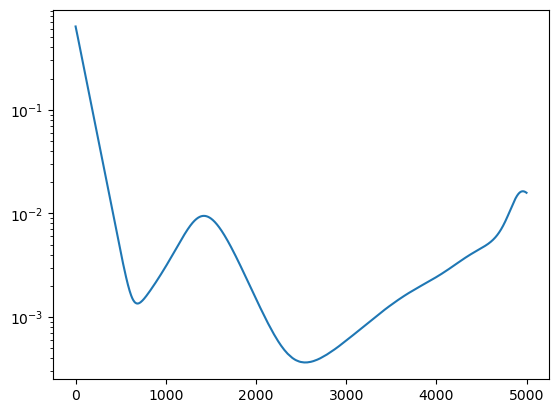

In [8]:
plt.plot(diff)
plt.yscale('log')

In [9]:
corr_2d = pair_correlation_2D(to_numpy(qsr*qsr_d))

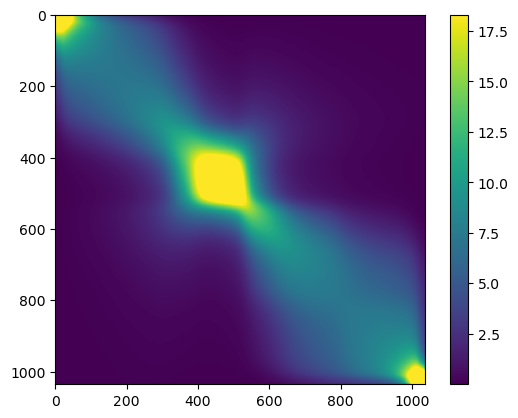

In [10]:
dynamic_range = 3 * np.std(corr_2d)
plt.imshow(corr_2d, cmap='viridis', interpolation='nearest', aspect=1,
           #vmin=-dynamic_range,
           vmax=+dynamic_range
           )

plt.colorbar()

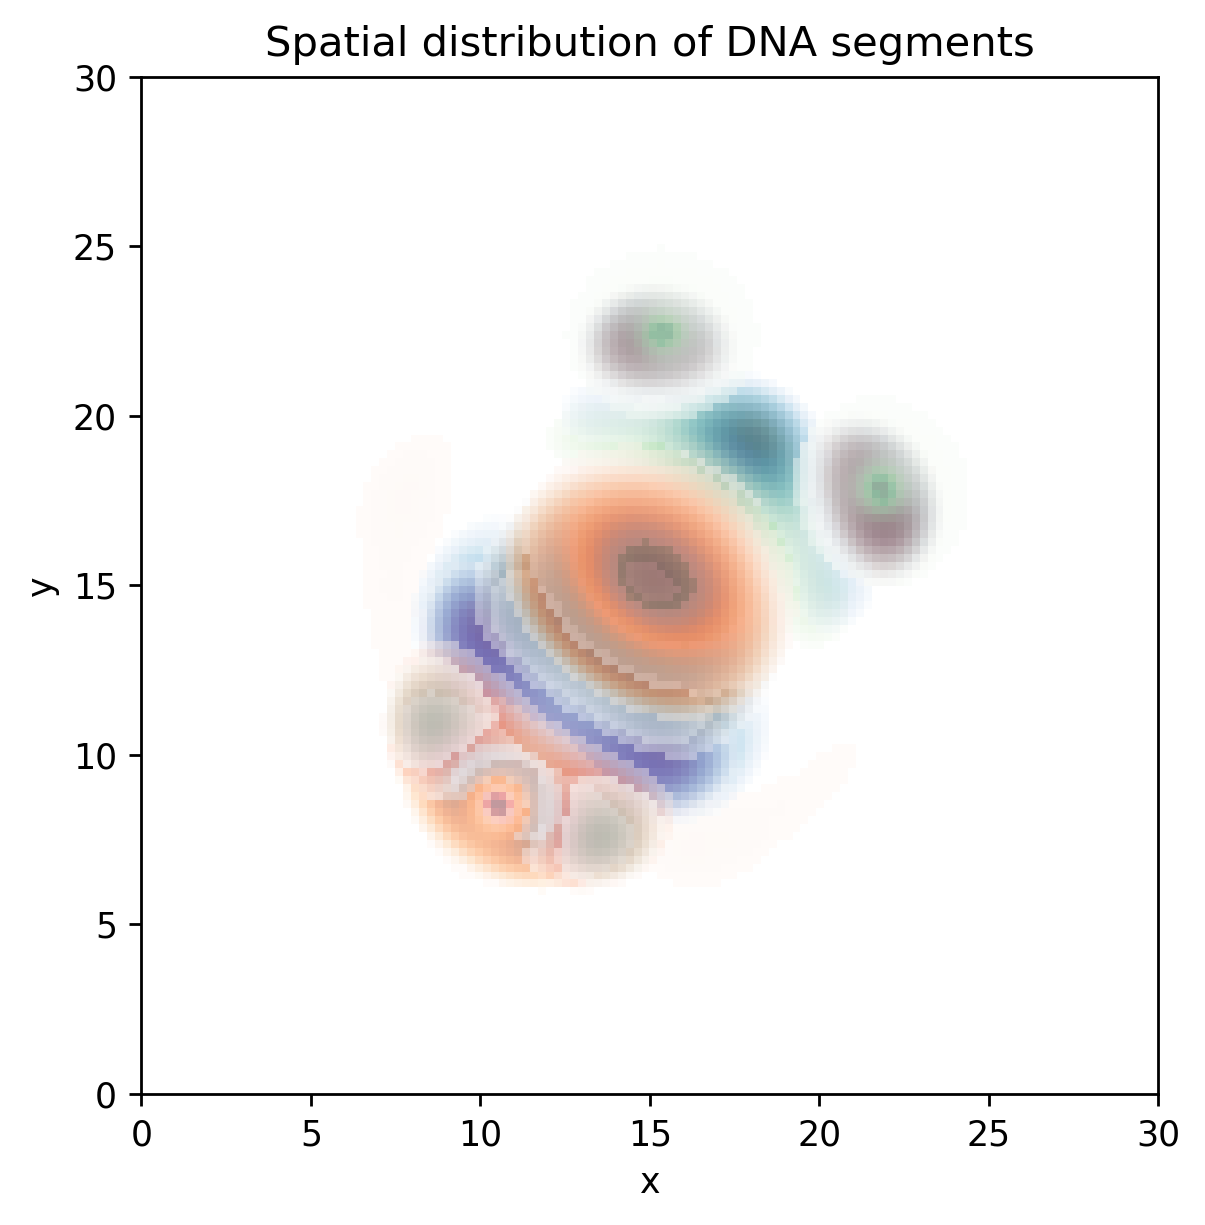

In [19]:
plot_phi_blocks_periodic(np.flip(to_numpy(phi_blocks), axis=0), extent=(0, polymer.Lx, 0, polymer.Ly), percentile=95, shift_x=0, shift_y=0)

27.76893586255183


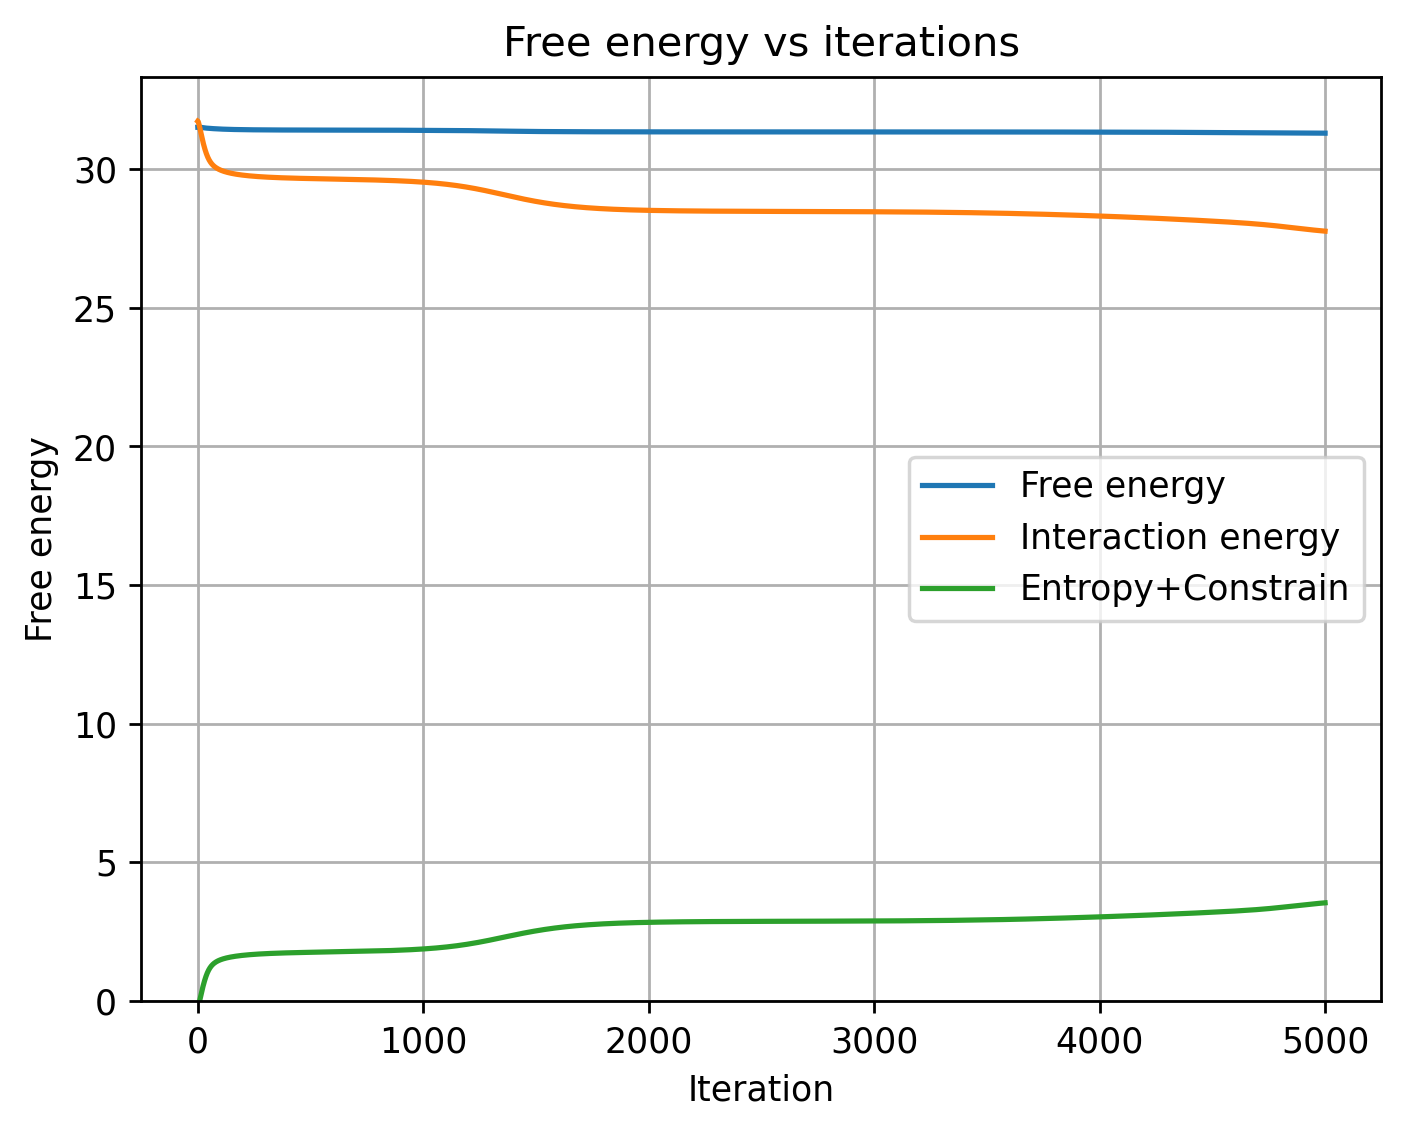

In [12]:
plt.figure(dpi=250)
free_energy_hist_plot = np.array(free_energy_hist)
plt.plot(free_energy_hist_plot[:, 0],label="Free energy")
plt.plot(free_energy_hist_plot[:, 1],label="Interaction energy")
plt.plot(free_energy_hist_plot[:, 2],label="Entropy+Constrain")
#plt.yscale('log')
plt.title("Free energy vs iterations")
plt.ylabel("Free energy")
plt.xlabel("Iteration")
plt.legend()
plt.grid()
plt.ylim(bottom = 0)
print(free_energy_hist[-1][1])

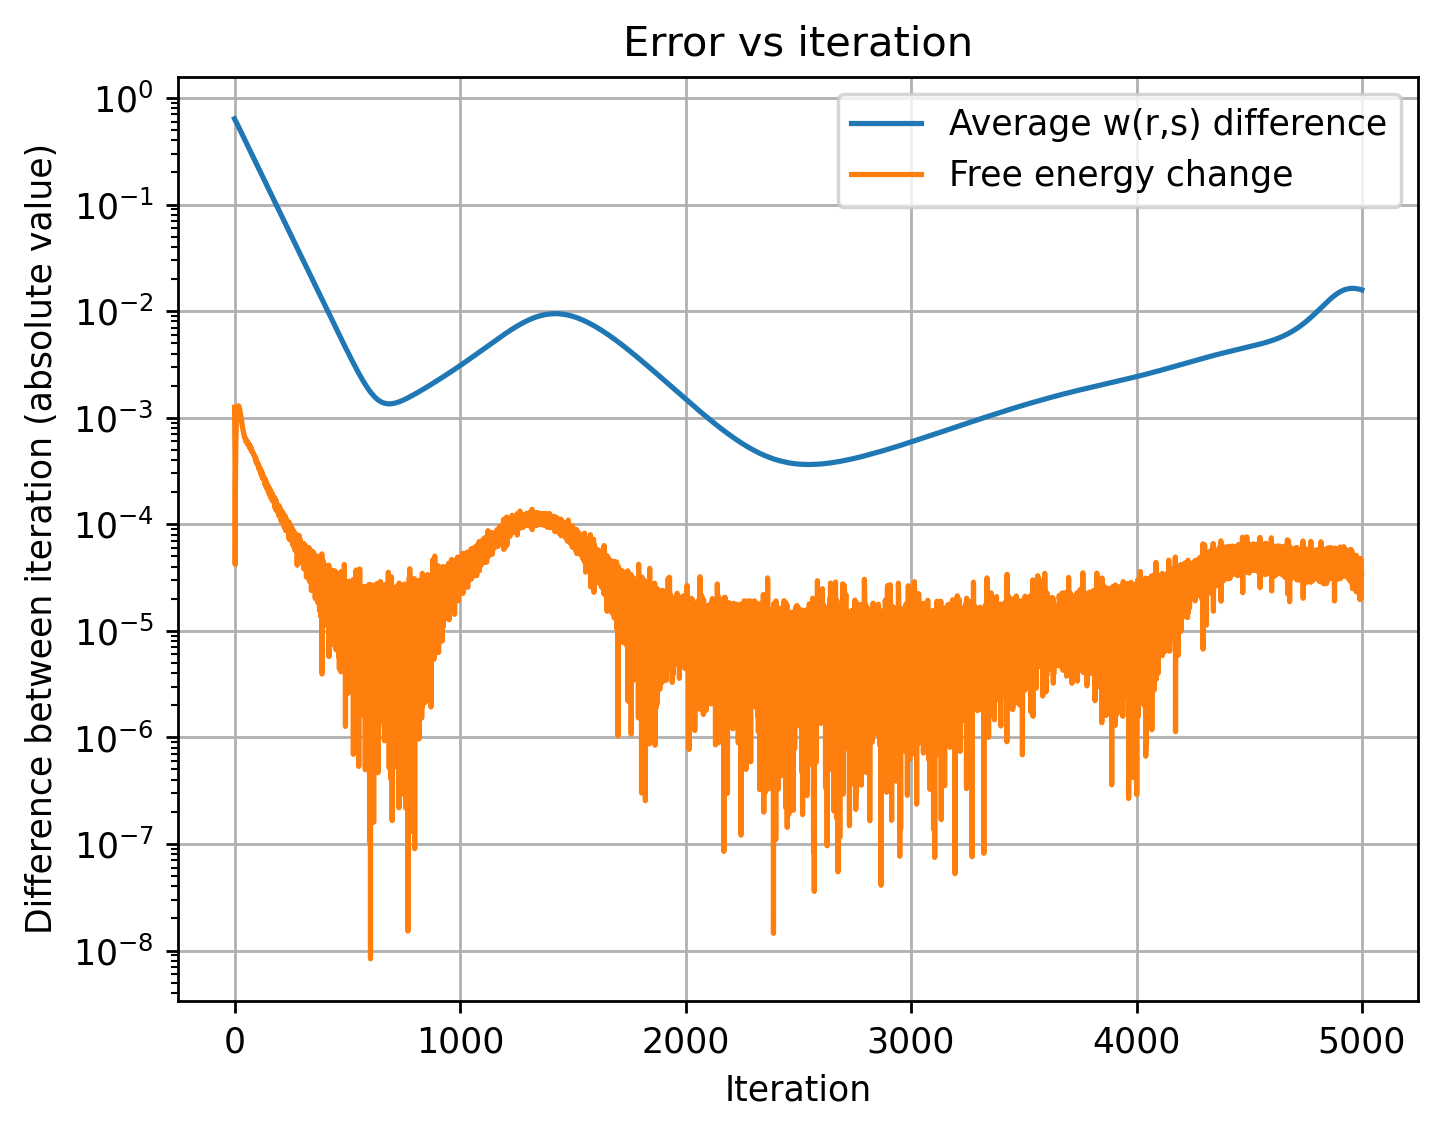

In [13]:
plt.figure(dpi=250)
plt.plot(diff, label="Average w(r,s) difference")
diff_energy = free_energy_hist_plot[1:, 0]-free_energy_hist_plot[:-1, 0]
plt.plot(abs(diff_energy), label="Free energy change")
plt.yscale('log')
#plt.title("Average difference in w(r,s) per iteration")
plt.title("Error vs iteration")
plt.ylabel("Difference between iteration (absolute value)")
plt.xlabel("Iteration")
plt.grid()
plt.legend()

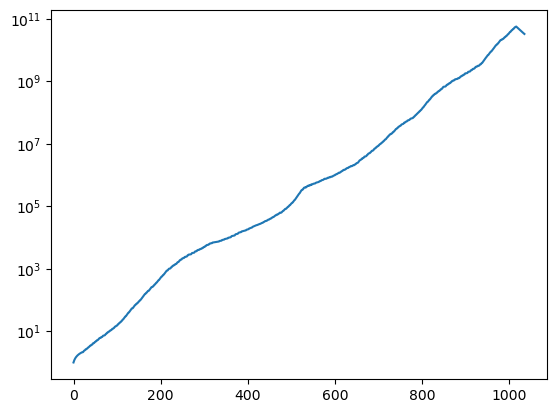

In [14]:
qsr_decay = np.mean(qsr, axis = (1,2))
plt.plot(to_numpy(qsr_decay))
plt.yscale('log')

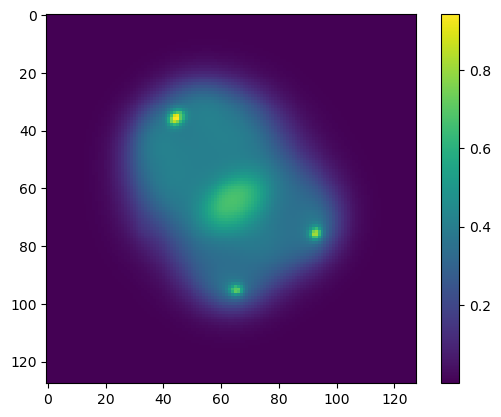

In [15]:
plt.imshow(to_numpy(phi), cmap='viridis', interpolation='nearest', aspect=1)
plt.colorbar()

In [16]:
# -------------------------------------------------------------
# Fast isosurface viewer for a (ns, nx, ny) polymer-density cube
# -------------------------------------------------------------
import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display


def show_polymer_isosurface(
    data,
    target_shape=(64, 64, 64),
    initial_percent=5.0,          # densest % per plane to keep at start
):
    """
    Down-sample *data* and display an interactive isosurface.

    Parameters
    ----------
    data : ndarray, shape (ns, nx, ny)
        Full-resolution density cube.
    target_shape : tuple(int,int,int)
        (ns, nx, ny) resolution used for display.
    initial_percent : float
        Planar densest-percent value used on launch.
    """
    # ── 1. down-sample by simple strided slicing ──────────────────────────
    ns0, nx0, ny0 = data.shape
    ns_t, nx_t, ny_t = target_shape

    idx_ns = np.linspace(0, ns0 - 1, ns_t, dtype=int) if ns0 > ns_t else np.arange(ns0)
    idx_x  = np.linspace(0, nx0 - 1, nx_t, dtype=int) if nx0 > nx_t else np.arange(nx0)
    idx_y  = np.linspace(0, ny0 - 1, ny_t, dtype=int) if ny0 > ny_t else np.arange(ny0)

    cube = data[np.ix_(idx_ns, idx_x, idx_y)].copy()          # (ns, nx, ny)
    ns, nx, ny = cube.shape

    # grids for plotting
    zz, xx, yy = np.indices(cube.shape, dtype=np.int16)
    x_flat, y_flat, z_flat = xx.ravel(), yy.ravel(), zz.ravel()

    # helper: top-X % mask per individual x-y plane
    def densest_mask_per_plane(arr, percent):
        if percent <= 0:
            return np.zeros_like(arr, dtype=bool)
        if percent >= 100:
            return np.ones_like(arr, dtype=bool)

        # percentile threshold for each ns-slice
        p_cut = 100.0 - percent
        thr = np.percentile(arr.reshape(ns, -1), p_cut, axis=1)[:, None, None]
        return arr >= thr

    # ── 2. build initial mask & figure ────────────────────────────────────
    mask = densest_mask_per_plane(cube, initial_percent)
    mask_f = mask.astype(np.float32).ravel()

    iso = go.Isosurface(
        x=x_flat, y=y_flat, z=z_flat,
        value=mask_f,
        isomin=0.5, isomax=1.0,
        surface_count=1,
        showscale=False,
        caps=dict(x_show=False, y_show=False, z_show=False),
    )
    fig = go.FigureWidget(data=[iso])
    fig.update_layout(
        scene=dict(
            xaxis_title='x', yaxis_title='y', zaxis_title='ns',
            aspectmode='data',
        ),
        margin=dict(l=0, r=0, t=0, b=0)
    )

    # ── 3. sliders (ipywidgets) ───────────────────────────────────────────
    dx_slider = widgets.IntSlider(value=0, min=-nx//2, max=nx//2, step=1,
                                  description='Δx')
    dy_slider = widgets.IntSlider(value=0, min=-ny//2, max=ny//2, step=1,
                                  description='Δy')
    pct_slider = widgets.FloatSlider(value=initial_percent, min=0, max=50,
                                     step=0.5, description='densest %')

    # ── 4. callback: recompute mask, apply rolls, update iso ──────────────
    def refresh(change=None):
        dx = dx_slider.value
        dy = dy_slider.value
        pct = pct_slider.value

        shifted = np.roll(np.roll(cube, dx, axis=1), dy, axis=2)
        mask_new = densest_mask_per_plane(shifted, pct)
        fig.data[0].value = mask_new.astype(np.float32).ravel()

    for w in (dx_slider, dy_slider, pct_slider):
        w.observe(refresh, names='value')

    # ── 5. display everything neatly ──────────────────────────────────────
    display(widgets.VBox([fig,
                          widgets.HBox([dx_slider, dy_slider]),
                          pct_slider]))
    return fig, (dx_slider, dy_slider, pct_slider)


In [17]:
show_polymer_isosurface(to_numpy(qsr*qsr_d),
                        target_shape=(64, 64, 64),
                        initial_percent=5.0)

    'data': [{'caps': {'x': {'show': False}, 'y': {'show': False}, 'z': {'show':…

(FigureWidget({
     'data': [{'caps': {'x': {'show': False}, 'y': {'show': False}, 'z': {'show': False}},
               'isomax': 1.0,
               'isomin': 0.5,
               'showscale': False,
               'surface': {'count': 1},
               'type': 'isosurface',
               'uid': '27f009bc-3224-4f62-bb7d-1509fc44191d',
               'value': array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
               'x': array([ 0,  0,  0, ..., 63, 63, 63], dtype=int16),
               'y': array([ 0,  1,  2, ..., 61, 62, 63], dtype=int16),
               'z': array([ 0,  0,  0, ..., 63, 63, 63], dtype=int16)}],
     'layout': {'margin': {'b': 0, 'l': 0, 'r': 0, 't': 0},
                'scene': {'aspectmode': 'data',
                          'xaxis': {'title': {'text': 'x'}},
                          'yaxis': {'title': {'text': 'y'}},
                          'zaxis': {'title': {'text': 'ns'}}},
                'template': '...'}
 }),
 (IntSlider(value=0, description='